# comparaison vent à 10m d'ERA5 et ERA5-Land

In [1]:
# importations

import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import os
import xclim as xc
import xscen as xs
import xesmf as xe

# constantes
r_era5 = "/exec/biner/1_projets/climato_vent_202509/data/reconstruction_NAM/ECMWF/ERA5/1hr"
r_era5l = "/exec/biner/1_projets/climato_vent_202509/data/reconstruction_NAM/ECMWF/ERA5-Land/1hr"

date="2020-01"


In [2]:
# chargement des données

nom_ua = "uas"
nom_va = "vas"

# era5
ua = xr.open_mfdataset(os.path.join(r_era5, nom_ua, f"{nom_ua}_*"), engine="zarr")[f"{nom_ua}"]
va = xr.open_mfdataset(os.path.join(r_era5, nom_va, f"{nom_va}_*"), engine="zarr")[f"{nom_va}"]

# calcul du module et de la direction du vent
(sfcwind_1hr, wind_dir)  = xc.indicators.atmos.wind_speed_from_vector(ua, va)
sfcwind_q_era5 = sfcwind_1hr.resample(time="1D").mean()


# era5l
ua = xr.open_mfdataset(os.path.join(r_era5l, nom_ua, f"{nom_ua}_*"), engine="zarr")[f"{nom_ua}"]
va = xr.open_mfdataset(os.path.join(r_era5l, nom_va, f"{nom_va}_*"), engine="zarr")[f"{nom_va}"]

# calcul du module et de la direction du vent
(sfcwind_1hr, wind_dir)  = xc.indicators.atmos.wind_speed_from_vector(ua, va)
sfcwind_q_era5l = sfcwind_1hr.resample(time="1D").mean()


In [5]:
# selection des dates voulues

da_era5_avg = sfcwind_q_era5.sel(time=date).mean(dim="time")
da_era5_std = sfcwind_q_era5.sel(time=date).std(dim="time")
da_era5l_avg = sfcwind_q_era5l.sel(time=date).mean(dim="time")
da_era5l_std = sfcwind_q_era5.sel(time=date).std(dim="time")

da_era5_avg.load()
da_era5l_avg.load()


# regrid sur la grille era5
#da_era5_avg
#regridder = xe.Regridder(da_era5l_avg, da_era5_avg, method="bilinear")
#da_era5l_avg_regrid = regridder(da_era5l_avg)
#xs.regrid.regrid_dataset(ds=da_era5l_avg, 
#    ds_grid=da_era5_avg, 
#   regridder_kwargs={'method': 'bilinear'})
#da_era5l_avg_regrid = xs.regrid.regrid_dataset(da_era5l_avg, da_era5_avg)

<xarray.DataArray 'sfcWind' (lat: 801, lon: 1700)> Size: 5MB
array([[      nan,       nan,       nan, ..., 2.0335639, 2.0241325,
        1.99359  ],
       [      nan,       nan,       nan, ..., 2.0192857, 2.0157087,
        1.9933168],
       [      nan,       nan,       nan, ..., 2.0207055, 2.0271702,
        2.0279574],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB 10.0 10.1 10.2 10.3 10.4 ... 89.7 89.8 89.9 90.0
  * lon      (lon) float32 7kB -179.9 -179.8 -179.7 -179.6 ... -10.2 -10.1 -10.0

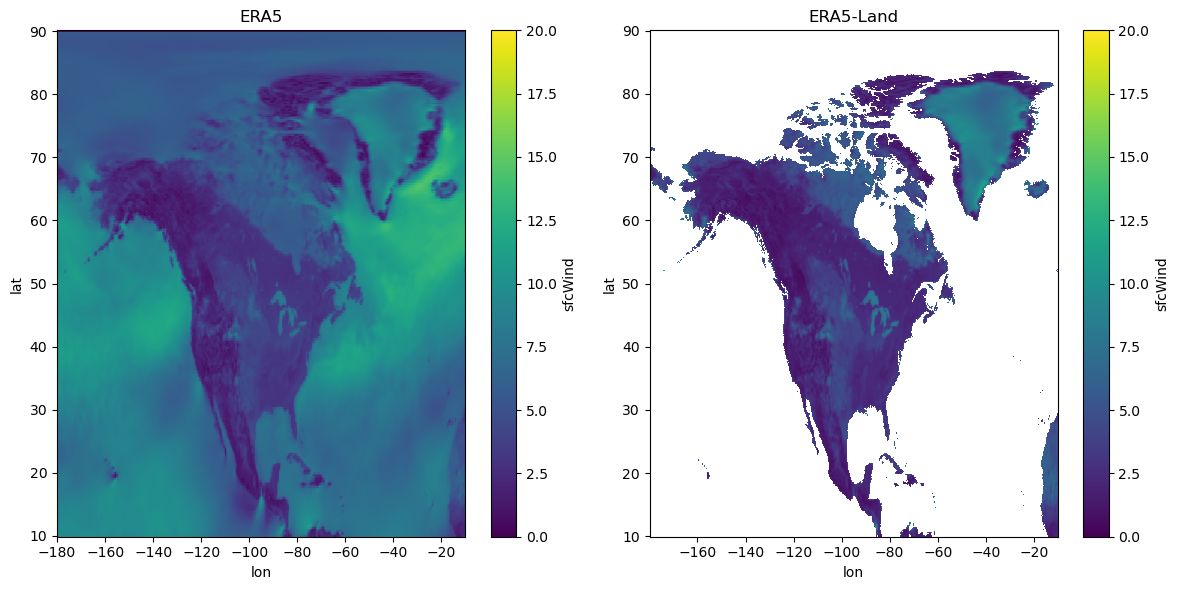

In [6]:
# affichage des champs

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
da_era5_avg.plot(ax=ax[0], vmin=0, vmax=20)
ax[0].set_title("ERA5")
da_era5l_avg.plot(ax=ax[1], vmin=0, vmax=20)
ax[1].set_title("ERA5-Land")
plt.tight_layout()
plt.show()  

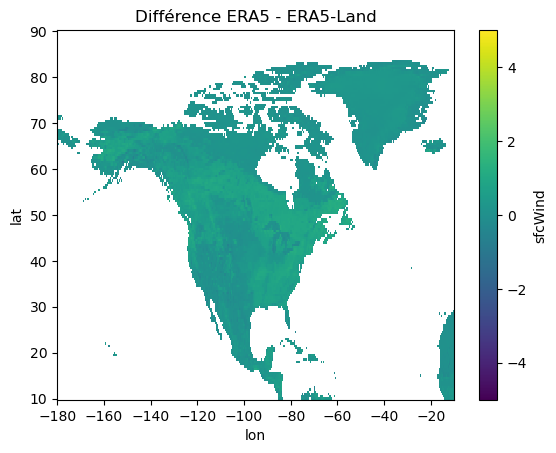

Moyenne de la différence : 0.3321586847305298
Écart-type de la différence : 0.31127697229385376
Valeur maximale de la différence : 1.5056695938110352
Valeur minimale de la différence : -0.8696966171264648
(321, 680)
(801, 1700)


<xarray.DataArray 'sfcWind' (lat: 161, lon: 340)> Size: 219kB
array([[       nan,        nan,        nan, ..., 0.31207561, 0.37407732,
        0.36653233],
       [       nan,        nan,        nan, ..., 0.25648618, 0.25712538,
        0.30711222],
       [       nan,        nan,        nan, ..., 0.2864324 , 0.4104259 ,
        0.29300046],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 644B 10.0 10.5 11.0 11.5 12.0 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float32 1kB -179.9 -179.4 -178.9 -178.4 ... -11.4 -10.9 -10.4

In [13]:
# on essaie de calculer la différence entre les deux champs
diff = da_era5_avg - da_era5l_avg
diff.plot(vmin=-5, vmax=5)
plt.title("Différence ERA5 - ERA5-Land")
plt.show()
print("Moyenne de la différence :", diff.mean().item())
print("Écart-type de la différence :", diff.std().item())
print("Valeur maximale de la différence :", diff.max().item())
print("Valeur minimale de la différence :", diff.min().item())
print(da_era5_avg.shape)
print(da_era5l_avg.shape)
diff 

In [14]:
# on fait un regridding de era5l sur la grille de era5
regridder = xe.Regridder(da_era5l_avg, da_era5_avg, method="bilinear")
da_era5l_avg_regrid = regridder(da_era5l_avg)

: 

In [ ]:
import xarray as xr

from xscen.regrid import regrid_dataset

from pathlib import Path

ds1 = xr.open_zarr(Path("/baril/scenario/datasets/reconstruction/NAM/ECMWF/ERA5-Land/1hr/tas/tas_1hr_NAM_ECMWF_ERA5-Land_1950-1957.zarr.zip"))

ds2 = xr.open_zarr(Path("/baril/scenario/datasets/reconstruction/NAM/ECMWF/ERA5/1hr/tas/tas_1hr_NAM_ECMWF_ERA5_1950-1957.zarr.zip") )

 

regrid_ds = regrid_dataset(ds1, ds2, regridder_kwargs= dict(method='bilinear'))

regrid_ds

: 